In [44]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
# Read data
file = 'Transactions.csv'
df = pd.read_csv(file)

print(df.head())

   Unnamed: 0.1  Unnamed: 0  TRANSACTION_ID          TX_DATETIME  CUSTOMER_ID  \
0             0           0               0  2023-01-01 00:00:31          596   
1             1           1               1  2023-01-01 00:02:10         4961   
2             2           2               2  2023-01-01 00:07:56            2   
3             3           3               3  2023-01-01 00:09:29         4128   
4             4           4               4  2023-01-01 00:10:34          927   

   TERMINAL_ID  TX_AMOUNT  TX_TIME_SECONDS  TX_TIME_DAYS  \
0         3156     533.07               31             0   
1         3412     808.56              130             0   
2         1365    1442.94              476             0   
3         8737     620.65              569             0   
4         9906     490.66              634             0   

                 TX_FRAUD_SCENARIO  
0           Legitimate Transaction  
1           Legitimate Transaction  
2  Fraudulent Transaction Internet  
3   

In [47]:
df = df.drop(columns=['Unnamed: 0.1','Unnamed: 0'])

In [48]:
# Data exploration
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   TRANSACTION_ID     int64  
 1   TX_DATETIME        object 
 2   CUSTOMER_ID        int64  
 3   TERMINAL_ID        int64  
 4   TX_AMOUNT          float64
 5   TX_TIME_SECONDS    int64  
 6   TX_TIME_DAYS       int64  
 7   TX_FRAUD_SCENARIO  object 
dtypes: float64(1), int64(5), object(2)
memory usage: 107.1+ MB


In [49]:
print(df.head())

   TRANSACTION_ID          TX_DATETIME  CUSTOMER_ID  TERMINAL_ID  TX_AMOUNT  \
0               0  2023-01-01 00:00:31          596         3156     533.07   
1               1  2023-01-01 00:02:10         4961         3412     808.56   
2               2  2023-01-01 00:07:56            2         1365    1442.94   
3               3  2023-01-01 00:09:29         4128         8737     620.65   
4               4  2023-01-01 00:10:34          927         9906     490.66   

   TX_TIME_SECONDS  TX_TIME_DAYS                TX_FRAUD_SCENARIO  
0               31             0           Legitimate Transaction  
1              130             0           Legitimate Transaction  
2              476             0  Fraudulent Transaction Internet  
3              569             0           Legitimate Transaction  
4              634             0           Legitimate Transaction  


In [50]:
df['TX_FRAUD_SCENARIO'].unique()

array(['Legitimate Transaction', 'Fraudulent Transaction Internet',
       'Fraudulent Transaction retailer', 'Fraudulent Transaction DAB'],
      dtype=object)

In [51]:
#df['TX_FRAUD_SCENARIO'] = df['TX_FRAUD_SCENARIO'].apply(lambda x: 'Legitimate Transaction' if x == 'Leg' else x)
#df['TX_FRAUD_SCENARIO'].unique()

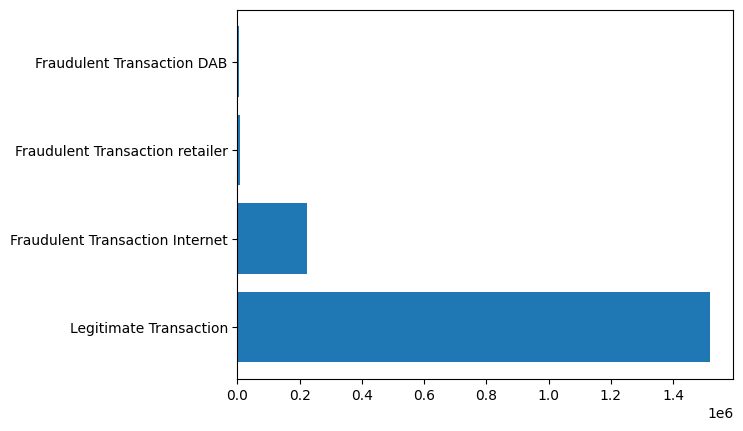

In [71]:
def plot_fraud_scenario_counts(data_frame):
    """
    Plots the counts of transactions for different fraud scenarios.

    :param data_frame: The DataFrame containing the data.
    """
    # Count the occurrences of each fraud scenario
    count_fraudes = data_frame['TX_FRAUD_SCENARIO'].value_counts()

    #cenarios
    cenarios = data_frame['TX_FRAUD_SCENARIO'].unique()

    fig, ax = plt.subplots()
    ax.barh(cenarios, count_fraudes)



# Call the function to plot fraud scenario counts
plot_fraud_scenario_counts(df)

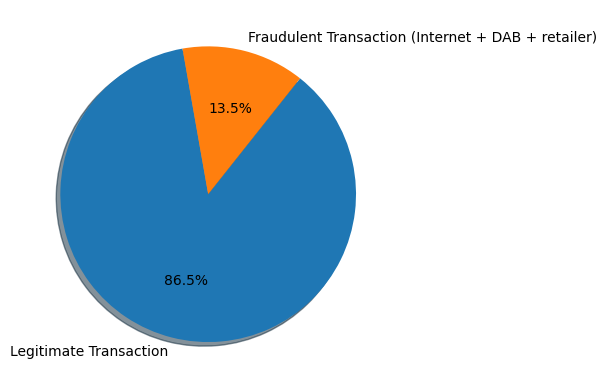

In [53]:
def plot_data_imbalance(data_frame, target_column):
    """
    Display a pie chart to illustrate class imbalance in the target column.

    :param data_frame: The DataFrame containing the data.
    :param target_column: The name of the target column for which the imbalance should be illustrated.
    """
    quantidade_cenario_fraude = data_frame[target_column].value_counts()

    transacoes_legitimas = quantidade_cenario_fraude.loc['Legitimate Transaction']
    transacoes_fraudulentas = quantidade_cenario_fraude.drop(index='Legitimate Transaction').sum()

    plt.pie([transacoes_legitimas,transacoes_fraudulentas],
            labels=['Legitimate Transaction','Fraudulent Transaction (Internet + DAB + retailer)'],
            autopct='%1.1f%%',
            startangle=100,
            shadow=True)


# Call the function to display class imbalance in the 'TX_FRAUD_SCENARIO' column
plot_data_imbalance(df, 'TX_FRAUD_SCENARIO')
# Think about merging your frauds together

In [54]:
df['TX_DATETIME'] = pd.to_datetime(df['TX_DATETIME'])
#df.set_index('TX_DATETIME', inplace=True)

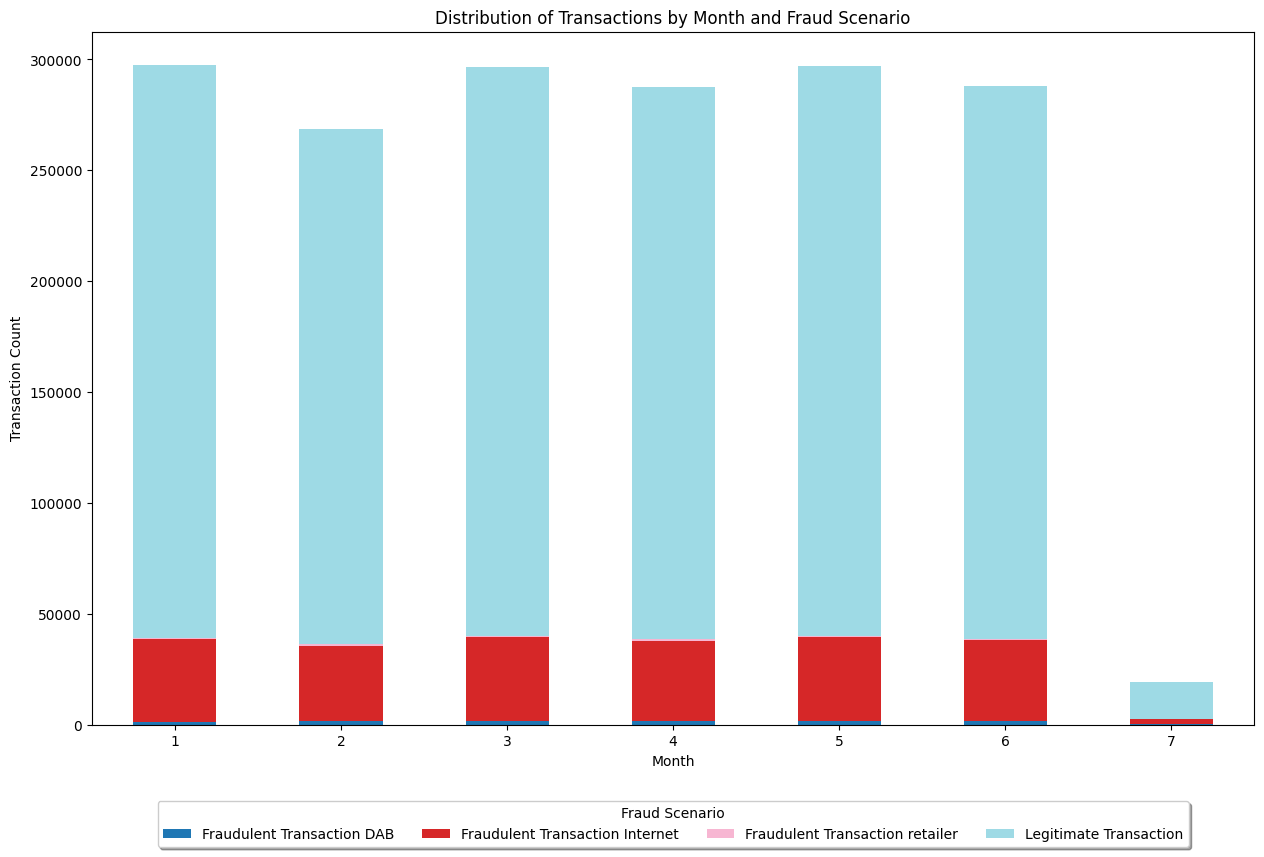

In [55]:
def visualize_monthly_transactions(df):
    """
    Visualizes the distribution of transactions per month and their fraud scenario using a grouped bar plot.

    :param df: DataFrame containing transaction data.
    """
    df['TX_MONTH'] = df['TX_DATETIME'].dt.month
    df_grouped = df.groupby(['TX_MONTH', 'TX_FRAUD_SCENARIO']).size().unstack()
    df_grouped.plot(kind='bar', stacked=True, colormap='tab20', figsize=(15, 9))
    plt.xlabel('Month')
    plt.ylabel('Transaction Count')
    plt.title('Distribution of Transactions by Month and Fraud Scenario')
    plt.xticks(rotation = 0)
    plt.legend(title='Fraud Scenario',loc='upper center', bbox_to_anchor=(0.5, -0.10),
          fancybox=True, shadow=True, ncol=5)
    plt.show()

# Call the function to visualize monthly transactions and fraud scenarios
visualize_monthly_transactions(df)

In [56]:
from imblearn.over_sampling import SMOTE
df.shape

(1754155, 9)

In [57]:
def balance_data_with_smote(df, target_column):
    """
    Balances the dataset using SMOTE to oversample the minority class.

    :param df: The DataFrame containing the data.
    :param target_column: The name of the target column for which the balancing is performed.
    :return: A balanced DataFrame.
    """
    X = df.drop(columns=[target_column, 'TX_DATETIME'])
    y = df[target_column]

    smote = SMOTE(random_state=42,sampling_strategy='minority')
    X_res, y_res = smote.fit_resample(X, y)
    balanced_df = pd.DataFrame(X_res, columns=X.columns)
    balanced_df[target_column] = y_res
    return balanced_df


# Balance the dataset using SMOTE based on the 'TX_FRAUD_SCENARIO' column
balanced_df = balance_data_with_smote(df, 'TX_FRAUD_SCENARIO')

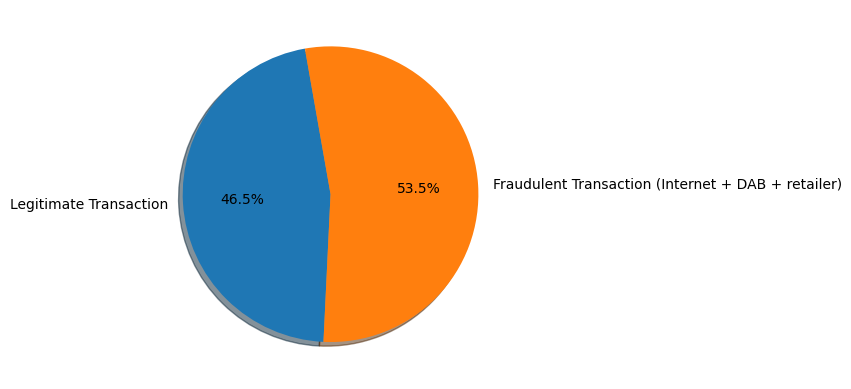

In [58]:
#def plot_data_imbalance(data_frame, target_column):
#    """
#    Display a pie chart to illustrate the class imbalance in the target column.
#
#    :param data_frame: The DataFrame containing the data.
#    :param target_column: The name of the target column for which the imbalance should be illustrated.
#    """
#    quantidade_cenario_fraude = data_frame[target_column].value_counts()
#
#    transacoes_legitimas = quantidade_cenario_fraude.loc['Legitimate Transaction']
#    transacoes_fraudulentas = quantidade_cenario_fraude.drop(index='Legitimate Transaction').sum()
#
#    plt.pie([transacoes_legitimas,transacoes_fraudulentas],
#            labels=['Legitimate Transaction','Fraudulent Transaction (Internet + DAB + retailer)'],
#            autopct='%1.1f%%',
#            startangle=100,
#            shadow=True)


# Call the function to display the class imbalance in the 'TX_FRAUD_SCENARIO' column
plot_data_imbalance(balanced_df, 'TX_FRAUD_SCENARIO')

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [67]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['TX_FRAUD_SCENARIO', 'TX_DATETIME'])
y = df['TX_FRAUD_SCENARIO']
#Treino         #Test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state=123)

print(f'X_train:{X_train.shape}, X_test:{X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}')

X_train:(1227908, 7), X_test:(526247, 7), y_train: (1227908,), y_test: (526247,)


In [62]:
X_train.head()

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_MONTH
1349879,1349879,2806,253,252.76,12156790,140,5
1012197,1012197,3188,29,603.92,9117567,105,4
616385,616385,3360,2513,249.11,5560435,64,3
30297,30297,1926,7090,821.79,283037,3,1
1551593,1551593,3029,4038,214.31,13976800,161,6


In [68]:
#Com Linear Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy_lr}")

Acurácia do modelo: 0.9931173004311663


In [70]:
# It's up to you to continue
# Remember to look in the module subject for more information on what to do next and on the benefits of this module, the following exercises are no longer guided.

In [69]:
#Com XGBoost
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

model = xgb.XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy}")

Acurácia do modelo: 0.9927923579611855


In [73]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

# Criar os modelos individuais
clf1 = DecisionTreeClassifier()
clf2 = LogisticRegression()
clf3 = KNeighborsClassifier()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criar o VotingClassifier
voting = VotingClassifier(
    estimators=[('dt', clf1), ('lr', clf2), ('knn', clf3)],
    voting='hard'  # 'hard' para votação por maioria, 'soft' para média ponderada das probabilidades
)

# Treinar o VotingClassifier
voting.fit(X_train_scaled, y_train)

# Fazer previsões
y_pred = voting.predict(X_test_scaled)

print(f"Acurácia do modelo: {accuracy_score(y_test, y_pred)}")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Acurácia do modelo: 0.9936170657504936


In [75]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

# Criar os modelos individuais
clf1 = DecisionTreeClassifier()
clf2 = LogisticRegression(max_iter=1000)
clf3 = KNeighborsClassifier()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criando o VotingClassifier
voting = VotingClassifier(
    estimators=[('dt', clf1), ('lr', clf2), ('knn', clf3)],
    voting='hard'  # 'hard' para votação por maioria, 'soft' para média ponderada das probabilidades
)


voting.fit(X_train_scaled, y_train)


y_pred = voting.predict(X_test_scaled)

print(f"Acurácia do modelo: {accuracy_score(y_test, y_pred)}")

Acurácia do modelo: 0.9936132652537687
